In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import geemap

from src.ndvi_ndwi import add_indices
from src.preprocess.aoi import load_city_aoi
from src.preprocess.gee_auth import initialize_ee
from src.preprocess.get_city_boundaries import Cities
from src.preprocess.load_and_preprocess_image import get_one_year_composite

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

initialize_ee()

In [2]:
CITY = Cities.BERLIN.value
YEAR = 2025

aoi = load_city_aoi(CITY.name)
image = add_indices(get_one_year_composite(aoi, YEAR))

In [3]:
import ee


def show_ndvi_map(aoi: ee.Geometry, image: ee.Image) -> geemap.Map:
    ndvi_vis = {"min": -1, "max": 1, "palette": ["#d73027", "#ffffbf", "#1a9850"]}

    Map = geemap.Map()
    Map.centerObject(aoi, zoom=11)
    Map.addLayer(image.select("NDVI"), ndvi_vis, "NDVI")
    Map.add_colorbar(ndvi_vis, label="NDVI")
    return Map


# show_ndvi_map(aoi, image)

In [4]:
import ee

from src.preprocess.load_and_preprocess_image import (
    END_YEAR,
    START_YEAR,
    get_one_year_composite,
)


def compute_ndvi_trend(
    aoi: ee.Geometry, start_year: int, end_year: int
) -> tuple[list[int], list[float]]:
    years = list(range(start_year, end_year + 1))
    mean_ndvi_values = []
    for year in years:
        image = add_indices(
            get_one_year_composite(aoi, year, start_month=6, end_month=8)
        )
        mean_ndvi = (
            image.select("NDVI")
            .reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=aoi,
                scale=30,
                bestEffort=True,
                maxPixels=1e9,
            )
            .get("NDVI")
            .getInfo()
        )
        mean_ndvi_values.append(mean_ndvi)
    return years, mean_ndvi_values

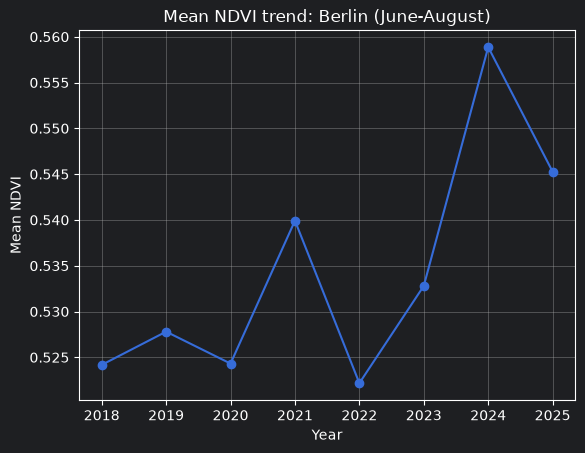

In [5]:
import matplotlib.pyplot as plt


def plot_ndvi_trend(
    years: list[int], mean_ndvi_values: list[float], city_name: str
) -> None:
    plt.plot(years, mean_ndvi_values, marker="o")
    plt.xlabel("Year")
    plt.ylabel("Mean NDVI")
    plt.title(
        f"Mean NDVI trend: {city_name} (June-August)"
    )  # TODO - take month name sin the title as variable
    plt.grid(True)
    plt.show()


years, mean_ndvi_values = compute_ndvi_trend(aoi, START_YEAR, END_YEAR)
plot_ndvi_trend(years, mean_ndvi_values, CITY.name)

In [21]:
CITY = Cities.BERLIN.value
aoi = load_city_aoi(CITY.name)


def compute_ndvi_diff(aoi: ee.Geometry, start_year: int, end_year: int) -> ee.Image:
    start_image = add_indices(
        get_one_year_composite(aoi, start_year, start_month=6, end_month=8)
    )
    end_image = add_indices(
        get_one_year_composite(aoi, end_year, start_month=6, end_month=8)
    )
    return (
        end_image.select("NDVI")
        .subtract(start_image.select("NDVI"))
        .rename("NDVI_diff")
    )


def show_ndvi_diff_map(aoi: ee.Geometry, start_year: int, end_year: int) -> geemap.Map:
    diff_image = compute_ndvi_diff(aoi, start_year, end_year)
    diff_vis = {"min": -0.3, "max": 0.3, "palette": ["#a50026", "#ffffbf", "#006837"]}

    Map = geemap.Map()
    Map.centerObject(aoi, zoom=11)
    Map.addLayer(diff_image, diff_vis, f"NDVI change {start_year}-{end_year}")
    Map.add_colorbar(diff_vis, label=f"NDVI change ({start_year}-{end_year})")
    return Map


# show_ndvi_diff_map(aoi, START_YEAR, END_YEAR)


def show_ndvi_diff_static(
    aoi: ee.Geometry, start_year: int, end_year: int, buffer_meters: int = 1000
) -> None:
    buffered_aoi = aoi.buffer(buffer_meters)
    diff_image = compute_ndvi_diff(aoi, start_year, end_year)
    diff_array = geemap.ee_to_numpy(
        diff_image, region=buffered_aoi, bands=["NDVI_diff"], scale=30
    )[:, :, 0]

    plt.figure(figsize=(8, 8))
    cmap = plt.get_cmap("RdYlGn").copy()
    cmap.set_bad(color="white")
    im = plt.imshow(diff_array, cmap=cmap, vmin=-0.3, vmax=0.3)
    plt.colorbar(
        im,
        fraction=0.02,
        pad=0.02,
        shrink=0.35,
        aspect=30,
    )
    plt.title(f"NDVI change: {CITY.name} ({start_year} to {end_year})")
    plt.axis("off")
    plt.show()


show_ndvi_diff_static(aoi, START_YEAR, END_YEAR)

EEException: User memory limit exceeded.